In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
import json

from models.custom_cnn import BaselineCNN
from models.transfer_models import TransferModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [22]:
transfer_results = pd.read_csv('../results/transfer_learning_comparison.csv')
aug_results = pd.read_csv('../results/augmentation_regularization.csv')

all_results = []

all_results.append({
    'Model': 'Baseline CNN',
    'Val Accuracy': 0.8693,
    'Test Accuracy': 0.866,
    'Time (min)': 13.20
})

if transfer_results is not None:
    print('✓ Loaded transfer learning results')
    for _, row in transfer_results.iterrows():
        all_results.append({
            'Model': f"{row['Model']} ({row['Mode']})",
            'Val Accuracy': row['Val Acc'],
            'Test Accuracy': float(row['Test Acc']),
            'Time (min)': row['Time (min)'],
        })

if aug_results is not None:
    print('✓ Loaded augmentation/regularization results')
    for _, row in aug_results.iterrows():
        all_results.append({
            'Model': row['Experiment'],
            'Val Accuracy': row['Val Acc'],
            'Test Accuracy': float(row['Test Acc']),
            'Time (min)': row['Time (min)'],
        })

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print(f'\n✓ Total models collected: {len(results_df)}')

✓ Loaded transfer learning results
✓ Loaded augmentation/regularization results

✓ Total models collected: 13


In [23]:

print(results_df.to_string(index=False))

results_df.to_csv('../results/final_comparison_summary.csv', index=False)
print('\n✓ Saved to: results/final_comparison_summary.csv')

best_model = results_df.iloc[0]
print(f'\nBEST MODEL: {best_model["Model"]}')
print(f'   Test Accuracy: {best_model["Test Accuracy"]:.4f}')

                   Model  Val Accuracy  Test Accuracy Time (min)
                Ensemble        0.9882         0.9370   Combined
    resnet18 (Finetuned)        0.9412         0.9333       4.35
            Combined Reg        0.9900         0.9330      11.50
         Label Smoothing        0.9861         0.9303      11.46
    resnet50 (Finetuned)        0.9387         0.9290        5.9
            Advanced Aug        0.9669         0.9287      22.66
            Weight Decay        0.9815         0.9253       7.66
            Baseline Aug        0.9804         0.9217       8.04
   mobilenet_v2 (Frozen)        0.9241         0.9140       6.64
       resnet50 (Frozen)        0.9245         0.9120      12.84
       resnet18 (Frozen)        0.9223         0.9063       9.37
efficientnet_b0 (Frozen)        0.9116         0.8940       8.61
            Baseline CNN        0.8693         0.8660       13.2

✓ Saved to: results/final_comparison_summary.csv

BEST MODEL: Ensemble
   Test Accuracy: 

In [24]:
data_dir = '../dataSet/archive/seg_train/seg_train'
test_dir = '../dataSet/archive/seg_test/seg_test'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

class_names = test_dataset.classes
print(f'Classes: {class_names}')
print(f'Test samples: {len(test_dataset)}')

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Test samples: 3000


In [25]:
def load_model_for_ensemble(checkpoint_path, model_name):
    model = TransferModel(model_name=model_name, num_classes=6, pretrained=False).to(device)

    state_dict = torch.load(checkpoint_path, map_location=device)

    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('base_model.base_model.'):
            new_key = key.replace('base_model.base_model.', 'base_model.')
            new_state_dict[new_key] = value
        else:
            new_state_dict[key] = value

    model.load_state_dict(new_state_dict)
    model.eval()
    return model


models_for_ensemble = [
    load_model_for_ensemble('../checkpoints/aug_baseline.pth', 'resnet18'),
    load_model_for_ensemble('../checkpoints/aug_advanced.pth', 'resnet18'),
    load_model_for_ensemble('../checkpoints/ensemble_model_1.pth', 'resnet50')
]


C:\Users\zhenu\anaconda3\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\zhenu\anaconda3\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\zhenu\AppData\Local\Temp\ipykernel_9956\174129427.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `

In [26]:
def ensemble_predict(models, loader, device):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            batch_preds = []
            for model in models:
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1)
                batch_preds.append(probs)

            avg_probs = torch.stack(batch_preds).mean(dim=0)
            predictions = avg_probs.argmax(dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

test_preds, test_labels = ensemble_predict(models_for_ensemble, test_loader, device)

accuracy = (test_preds == test_labels).sum() / len(test_labels)
print(f'Ensemble Test Accuracy: {accuracy:.4f}')

Ensemble Test Accuracy: 0.9370


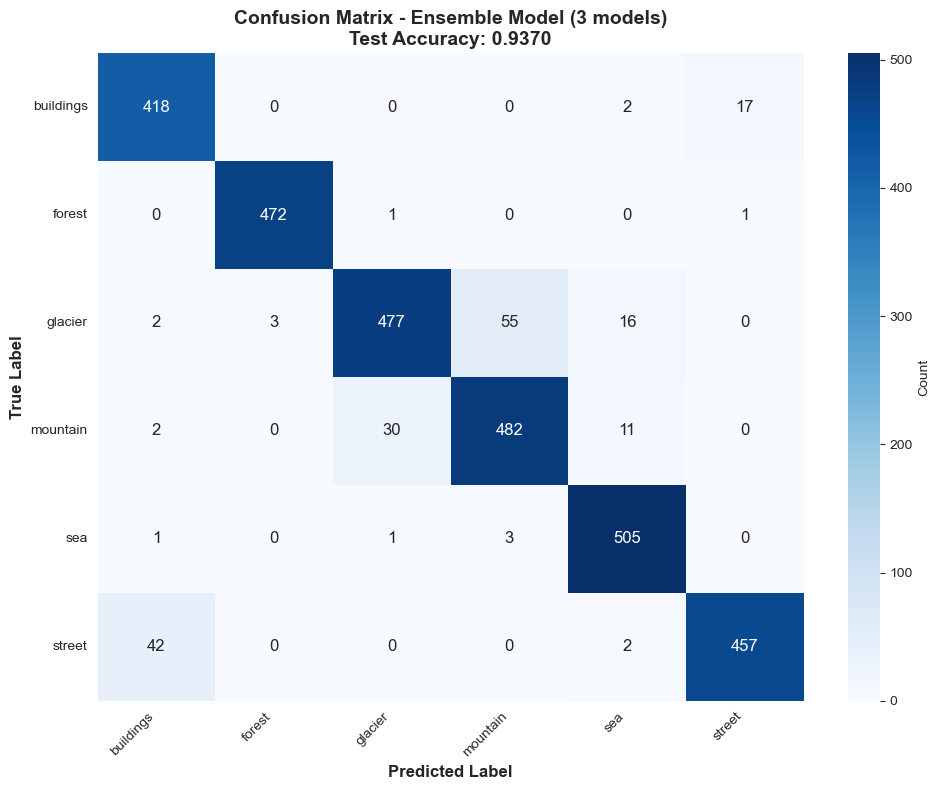


✓ Confusion matrix saved to: results/confusion_matrix_ensemble.png


In [27]:
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=ax, annot_kws={'size': 12})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix - Ensemble Model (3 models)\nTest Accuracy: {accuracy:.4f}',
            fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/confusion_matrix_ensemble.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ Confusion matrix saved to: results/confusion_matrix_ensemble.png')